In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn.preprocessing import PolynomialFeatures,StandardScaler
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

In [10]:
X=6*np.random.rand(200,1)-3
y=0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200,1)

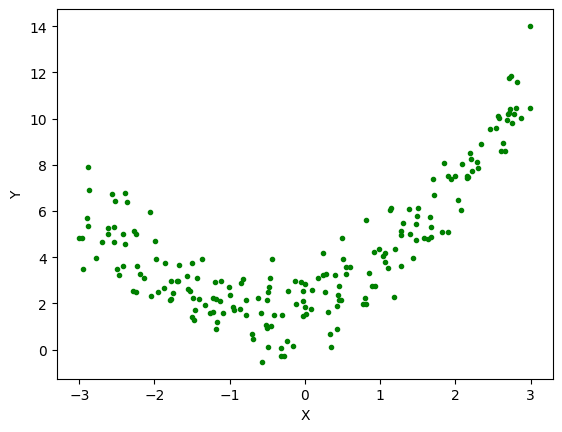

In [11]:
plt.plot(X,y,"g.")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [12]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [13]:
lr=LinearRegression()
lr.fit(X_train,y_train)
y_pred=lr.predict(X_test)
r2_score(y_test,y_pred)

0.2759319466643473

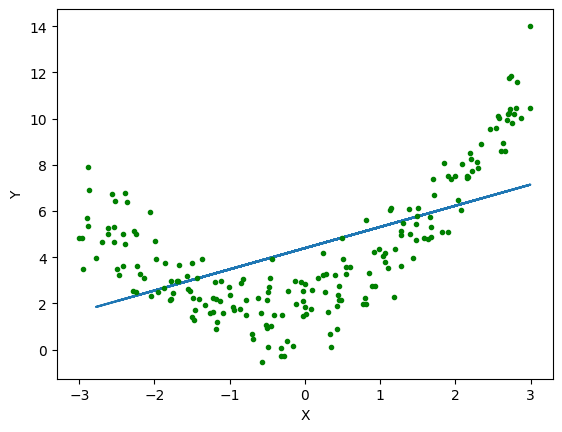

In [14]:
plt.plot(X_test,y_pred)
plt.plot(X,y,'g.')
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [15]:
poly=PolynomialFeatures(degree=2)
X_train_trans=poly.fit_transform(X_train)
X_test_trans=poly.transform(X_test)

In [16]:
print(X_train[0])
print(X_train_trans[0])

[2.20015338]
[1.         2.20015338 4.84067492]


Use include_bias=True to remove bias term i.e., 1

In [17]:
lr=LinearRegression()
lr.fit(X_train_trans,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
y_pred=lr.predict(X_test_trans)
r2_score(y_test,y_pred)

0.8510090095359544

In [19]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.92425755 0.75738242]]
[2.14783921]


In [21]:
X_new=np.linspace(-3,3,200).reshape(200,1)
X_new_poly=poly.transform(X_new)
y_new=lr.predict(X_new_poly)

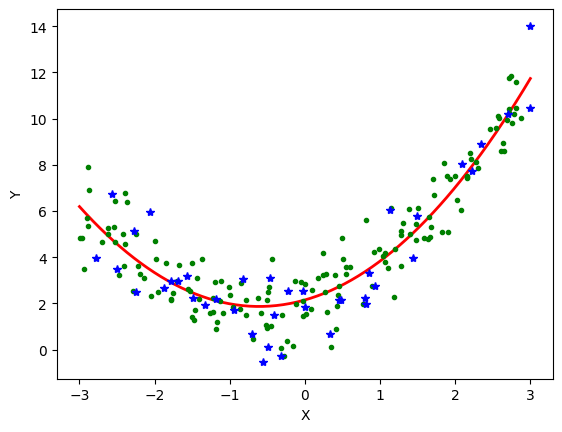

In [24]:
plt.plot(X_new,y_new,'r-',linewidth=2)
plt.plot(X_train,y_train,'g.')
plt.plot(X_test,y_test,'b*')
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [34]:
def polynomial_regression(degree):
    X_new=np.linspace(-3, 3, 100).reshape(100, 1)

    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    model = Pipeline([
            ("poly_features", polybig_features),
            ("std_scaler", std_scaler),
            ("lin_reg", lin_reg),
        ])
    model.fit(X, y)
    y_newbig = model.predict(X_new)
    plt.plot(X_new, y_newbig,'r', label="Degree " + str(degree), linewidth=2)

    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-3, 3, 0, 10])
    plt.show()

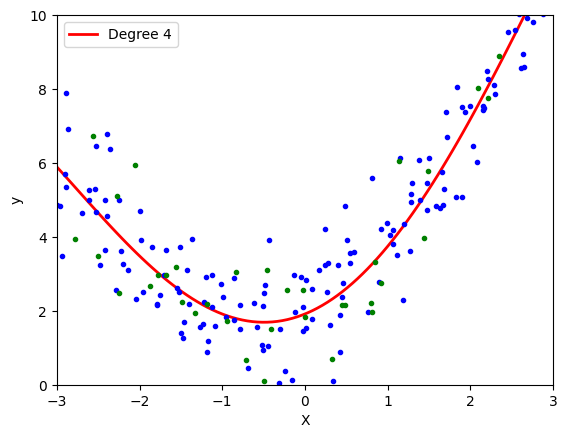

In [35]:
polynomial_regression(4)